#   Dataset Setup & Exploration



In [ ]:
import os
import zipfile
import shutil
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


# UPLOAD THE DATASET

In [ ]:
from google.colab import files

print(" Please upload the Gurmukhi dataset ZIP file")

uploaded = files.upload()

ZIP_NAME = list(uploaded.keys())[0]

print("\n✅ Dataset uploaded successfully!")
print("File:", ZIP_NAME)

 Please upload the Gurmukhi dataset ZIP file


Saving Gurmukhi dataset.zip to Gurmukhi dataset (1).zip

✅ Dataset uploaded successfully!
File: Gurmukhi dataset (1).zip


# EXTRACT THE DATASET

In [ ]:
EXTRACT_PATH = "/content/gurmukhi_dataset"

# Remove previous extraction if it exists
if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

os.makedirs(EXTRACT_PATH)

# Extract ZIP
with zipfile.ZipFile(ZIP_NAME, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!")
print("Extraction location:", EXTRACT_PATH)

Dataset extracted successfully!
Extraction location: /content/gurmukhi_dataset


# FIND DATASET FOLDER

In [ ]:
# ============================================
# EXTRACT INNER DATASET ZIP
# ============================================

INNER_ZIP = os.path.join(
    EXTRACT_PATH,
    "Gurmukhi dataset",
    "archive.zip"
)

FINAL_DATASET_PATH = "/content/gurmukhi_final"

# Remove old folder if it exists
if os.path.exists(FINAL_DATASET_PATH):
    shutil.rmtree(FINAL_DATASET_PATH)

os.makedirs(FINAL_DATASET_PATH)

print(" Extracting inner dataset ZIP...")
print("ZIP:", INNER_ZIP)

with zipfile.ZipFile(INNER_ZIP, "r") as zip_ref:
    zip_ref.extractall(FINAL_DATASET_PATH)

print("\n Inner dataset extracted successfully!")

 Extracting inner dataset ZIP...
ZIP: /content/gurmukhi_dataset/Gurmukhi dataset/archive.zip

 Inner dataset extracted successfully!


In [ ]:
# ============================================
# FIND THE 41 GURMUKHI CLASS FOLDERS
# ============================================

print("🔍 Finding character class folders...\n")

DATASET_PATH = None

for root, dirs, files_list in os.walk(FINAL_DATASET_PATH):

    class_folders_found = [
        d for d in dirs
        if d.isdigit() and 1 <= int(d) <= 41
    ]

    if len(class_folders_found) >= 35:

        DATASET_PATH = root
        break

if DATASET_PATH is not None:

    class_folders = sorted(
        class_folders_found,
        key=lambda x: int(x)
    )

    print(" DATASET FOUND!")
    print(" Path:", DATASET_PATH)
    print(" Number of classes:", len(class_folders))
    print(" Classes:", class_folders)

else:

    print(" Could not find the 41 class folders.")
    print("\nExtracted structure:")

    for root, dirs, files_list in os.walk(FINAL_DATASET_PATH):
        print(root)
        print("Folders:", dirs[:10])
        print("Files:", files_list[:10])
        print("-" * 50)

🔍 Finding character class folders...

 DATASET FOUND!
 Path: /content/gurmukhi_final/b
 Number of classes: 41
 Classes: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41']


# COUNT IMAGES IN EACH CLASS

In [ ]:
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

class_counts = {}

for class_name in class_folders:

    class_path = os.path.join(
        DATASET_PATH,
        class_name
    )

    image_files = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    class_counts[class_name] = len(image_files)


# Create a DataFrame
class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

# Sort by class number
class_distribution["Class"] = class_distribution["Class"].astype(int)

class_distribution = class_distribution.sort_values(
    "Class"
).reset_index(drop=True)

class_distribution["Class"] = (
    class_distribution["Class"].astype(str)
)


# Display results
print("=" * 55)
print("          GURMUKHI CLASS DISTRIBUTION")
print("=" * 55)

print(class_distribution.to_string(index=False))

print("\n" + "=" * 55)

total_images = class_distribution["Number of Images"].sum()

print(f"Total Images      : {total_images}")
print(f"Number of Classes : {len(class_distribution)}")
print(
    f"Average per Class : "
    f"{class_distribution['Number of Images'].mean():.2f}"
)

          GURMUKHI CLASS DISTRIBUTION
Class  Number of Images
    1               297
    2               299
    3               294
    4               295
    5               297
    6               296
    7               293
    8               297
    9               295
   10               294
   11               292
   12               296
   13               296
   14               299
   15               294
   16               298
   17               297
   18               296
   19               294
   20               297
   21               296
   22               295
   23               299
   24               296
   25               298
   26               297
   27               291
   28               297
   29               292
   30               299
   31               296
   32               298
   33               294
   34               294
   35               297
   36               299
   37               296
   38               297
   39               295
  

# VISUALIZE CLASS DISTRIBUTION

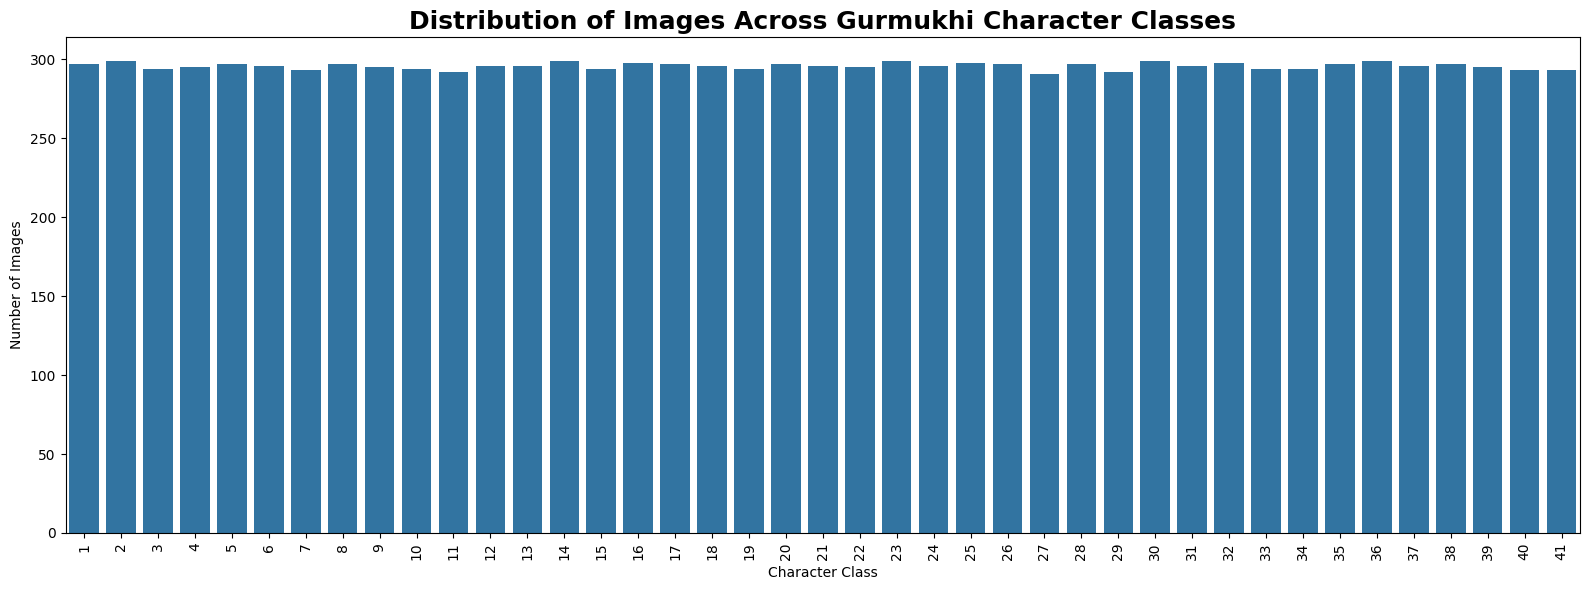

In [ ]:
plt.figure(figsize=(16, 6))

sns.barplot(
    data=class_distribution,
    x="Class",
    y="Number of Images"
)

plt.title(
    "Distribution of Images Across Gurmukhi Character Classes",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Character Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# DISPLAY SAMPLE IMAGES

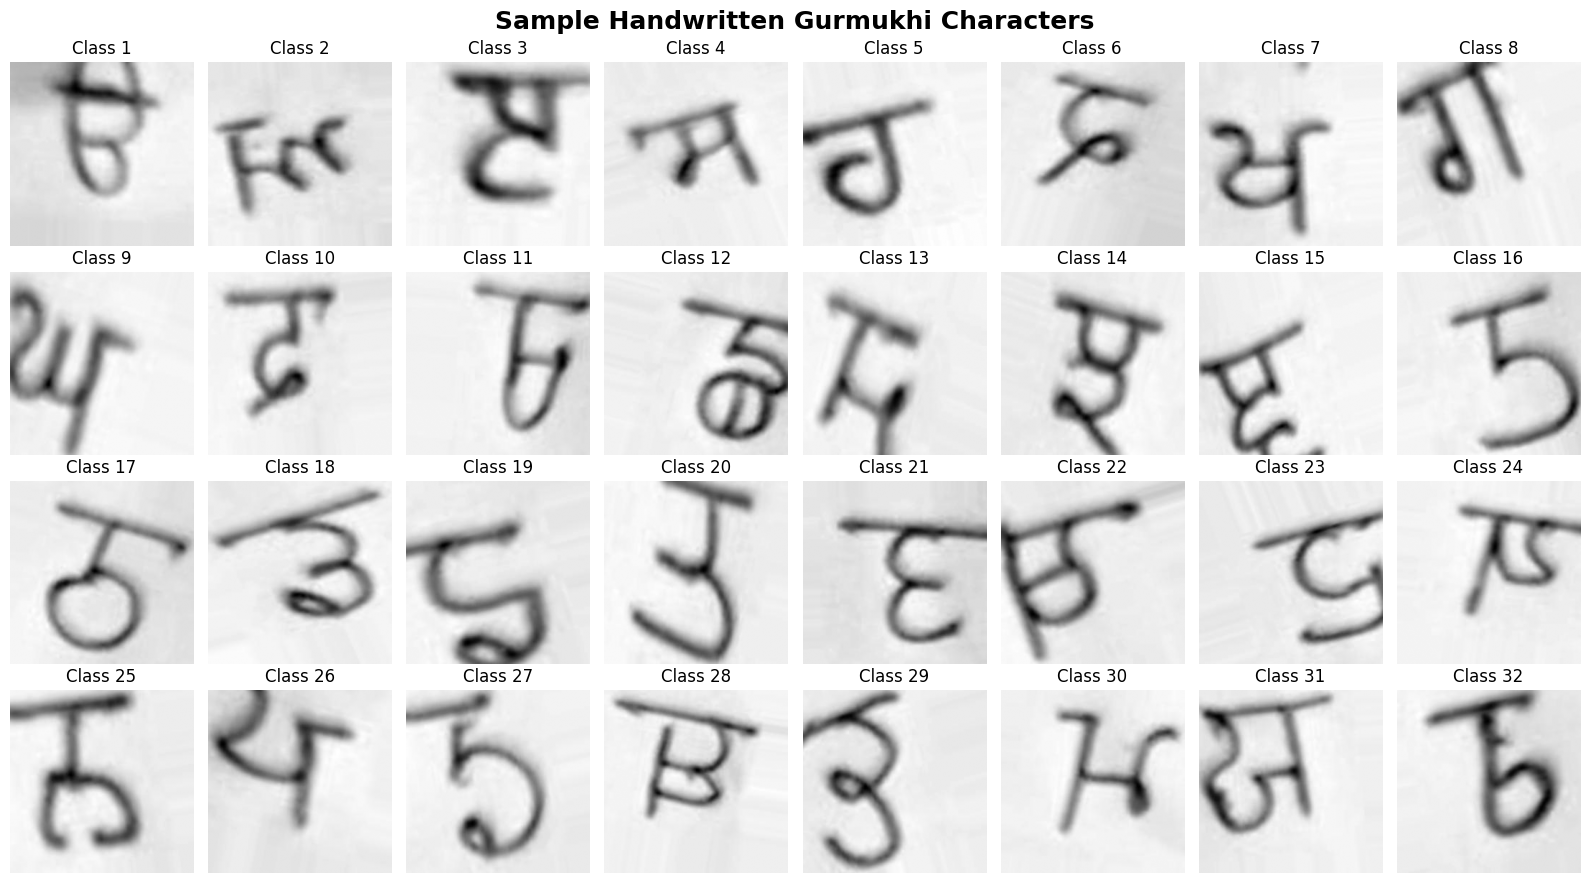

In [ ]:
fig, axes = plt.subplots(
    4,
    8,
    figsize=(16, 9)
)

selected_classes = class_folders[:32]

for ax, class_name in zip(
    axes.ravel(),
    selected_classes
):

    class_path = os.path.join(
        DATASET_PATH,
        class_name
    )

    image_files = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    image_file = random.choice(image_files)

    image_path = os.path.join(
        class_path,
        image_file
    )

    image = Image.open(image_path).convert("L")

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"Class {class_name}"
    )

    ax.axis("off")

plt.suptitle(
    "Sample Handwritten Gurmukhi Characters",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ANALYZE IMAGE DIMENSIONS


In [ ]:
dimensions = []

for class_name in class_folders:

    class_path = os.path.join(
        DATASET_PATH,
        class_name
    )

    image_files = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    for image_file in image_files[:10]:

        image_path = os.path.join(
            class_path,
            image_file
        )

        try:
            image = Image.open(image_path)
            dimensions.append(image.size)

        except:
            pass

dimension_counts = pd.Series(
    dimensions
).value_counts()

print(dimension_counts.head(15))

(256, 256)    410
Name: count, dtype: int64


# IMAGE PREPROCESSING

In [ ]:
# Image preprocessing configuration

IMAGE_SIZE = (32, 32)

print("Target image size:", IMAGE_SIZE)
print("Number of pixel features:", IMAGE_SIZE[0] * IMAGE_SIZE[1])

Target image size: (32, 32)
Number of pixel features: 1024


# LOAD AND PREPROCESS IMAGES

In [ ]:
X_images = []
y_labels = []
image_paths = []

for class_name in class_folders:

    class_path = os.path.join(
        DATASET_PATH,
        class_name
    )

    image_files = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    for image_file in image_files:

        image_path = os.path.join(
            class_path,
            image_file
        )

        try:
            image = Image.open(
                image_path
            ).convert("L")

            image = image.resize(
                IMAGE_SIZE,
                Image.Resampling.LANCZOS
            )

            image_array = np.array(
                image,
                dtype=np.float32
            )

            image_array = image_array / 255.0

            X_images.append(image_array)
            y_labels.append(class_name)
            image_paths.append(image_path)

        except Exception as e:
            print(
                f"Error loading {image_path}: {e}"
            )

X_images = np.array(X_images)
y_labels = np.array(y_labels)

print("Images loaded:", len(X_images))
print("Image shape:", X_images.shape)
print("Labels shape:", y_labels.shape)

Images loaded: 12128
Image shape: (12128, 32, 32)
Labels shape: (12128,)


# VISUALIZE PREPROCESSED IMAGES

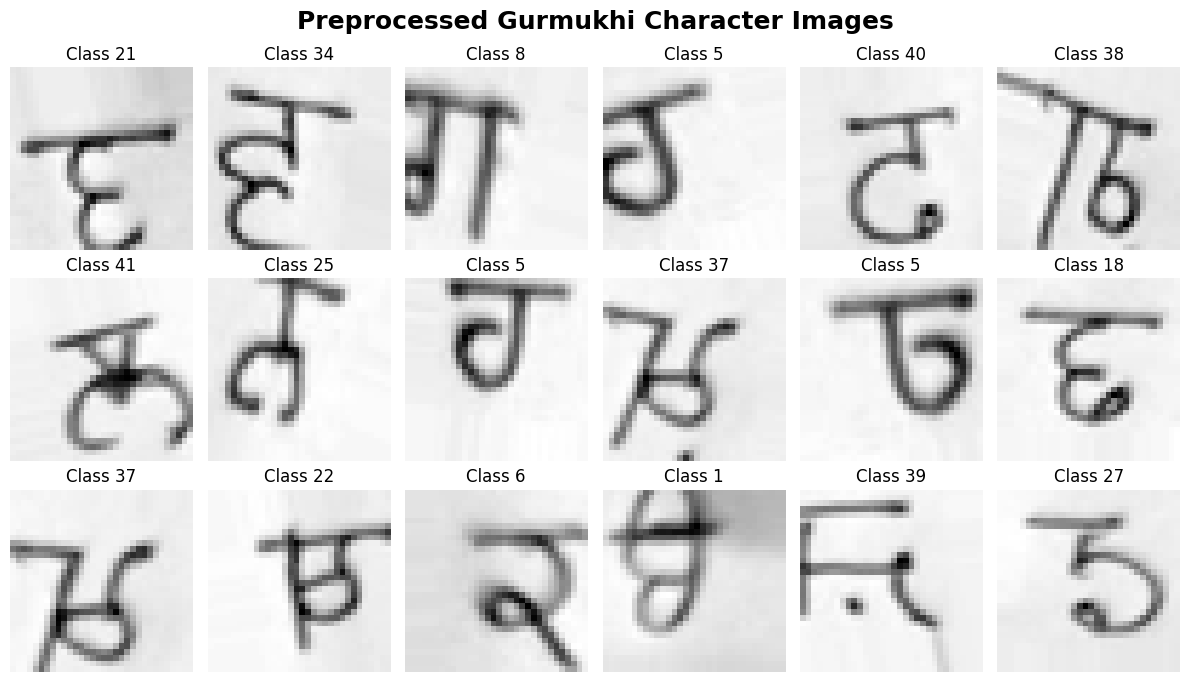

In [ ]:
fig, axes = plt.subplots(
    3,
    6,
    figsize=(12, 7)
)

sample_indices = np.random.choice(
    len(X_images),
    18,
    replace=False
)

for ax, index in zip(
    axes.ravel(),
    sample_indices
):

    ax.imshow(
        X_images[index],
        cmap="gray"
    )

    ax.set_title(
        f"Class {y_labels[index]}"
    )

    ax.axis("off")

plt.suptitle(
    "Preprocessed Gurmukhi Character Images",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# SPLIT THE DATASET

In [ ]:
from sklearn.model_selection import train_test_split

X_train_img, X_test_img, y_train, y_test, paths_train, paths_test = train_test_split(
    X_images,
    y_labels,
    image_paths,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_labels
)

print("Training images:", len(X_train_img))
print("Testing images:", len(X_test_img))
print("Training labels:", len(y_train))
print("Testing labels:", len(y_test))

Training images: 9702
Testing images: 2426
Training labels: 9702
Testing labels: 2426


# FEATURE EXTRACTION

In [ ]:
# Convert each 32 × 32 image into a 1D feature vector

X_train_raw = X_train_img.reshape(
    X_train_img.shape[0],
    -1
)

X_test_raw = X_test_img.reshape(
    X_test_img.shape[0],
    -1
)

print("Training feature shape:", X_train_raw.shape)
print("Testing feature shape:", X_test_raw.shape)

Training feature shape: (9702, 1024)
Testing feature shape: (2426, 1024)


# RANDOM FOREST CLASSIFIER

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_raw = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_raw.fit(
    X_train_raw,
    y_train
)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


# GENERATE PREDICTIONS

In [ ]:
y_pred_raw = rf_raw.predict(
    X_test_raw
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_raw))

Predictions generated successfully.
Number of predictions: 2426


# BASELINE MODEL EVALUATION


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_raw = accuracy_score(
    y_test,
    y_pred_raw
)

precision_raw = precision_score(
    y_test,
    y_pred_raw,
    average="macro"
)

recall_raw = recall_score(
    y_test,
    y_pred_raw,
    average="macro"
)

f1_raw = f1_score(
    y_test,
    y_pred_raw,
    average="macro"
)

print("=" * 45)
print("RANDOM FOREST BASELINE RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy_raw:.4f}")
print(f"Precision : {precision_raw:.4f}")
print(f"Recall    : {recall_raw:.4f}")
print(f"F1-Score  : {f1_raw:.4f}")

RANDOM FOREST BASELINE RESULTS
Accuracy  : 0.9575
Precision : 0.9580
Recall    : 0.9576
F1-Score  : 0.9574


# HOG FEATURE EXTRACTION

In [ ]:
from skimage.feature import hog

def extract_hog_features(images):
    features = []

    for image in images:

        hog_features = hog(
            image,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )

        features.append(hog_features)

    return np.array(features)


X_train_hog = extract_hog_features(X_train_img)
X_test_hog = extract_hog_features(X_test_img)

print("Training HOG feature shape:", X_train_hog.shape)
print("Testing HOG feature shape:", X_test_hog.shape)

Training HOG feature shape: (9702, 1764)
Testing HOG feature shape: (2426, 1764)


# RANDOM FOREST WITH HOG FEATURES

In [ ]:
rf_hog = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_hog.fit(
    X_train_hog,
    y_train
)

print("Random Forest with HOG features trained successfully.")

Random Forest with HOG features trained successfully.


# GENERATE HOG PREDICTIONS

In [ ]:
y_pred_hog = rf_hog.predict(
    X_test_hog
)

print("HOG predictions generated successfully.")
print("Number of predictions:", len(y_pred_hog))

HOG predictions generated successfully.
Number of predictions: 2426


# HOG MODEL EVALUATION

In [ ]:
accuracy_hog = accuracy_score(
    y_test,
    y_pred_hog
)

precision_hog = precision_score(
    y_test,
    y_pred_hog,
    average="macro"
)

recall_hog = recall_score(
    y_test,
    y_pred_hog,
    average="macro"
)

f1_hog = f1_score(
    y_test,
    y_pred_hog,
    average="macro"
)

print("=" * 45)
print("RANDOM FOREST + HOG RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy_hog:.4f}")
print(f"Precision : {precision_hog:.4f}")
print(f"Recall    : {recall_hog:.4f}")
print(f"F1-Score  : {f1_hog:.4f}")

RANDOM FOREST + HOG RESULTS
Accuracy  : 0.7852
Precision : 0.7903
Recall    : 0.7852
F1-Score  : 0.7846


# MODEL COMPARISON

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest + Raw Pixels",
        "Random Forest + HOG"
    ],
    "Accuracy": [
        accuracy_raw,
        accuracy_hog
    ],
    "Precision": [
        precision_raw,
        precision_hog
    ],
    "Recall": [
        recall_raw,
        recall_hog
    ],
    "F1-Score": [
        f1_raw,
        f1_hog
    ]
})

display(
    model_comparison.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest + Raw Pixels,95.75%,95.80%,95.76%,95.74%
1,Random Forest + HOG,78.52%,79.03%,78.52%,78.46%


# MODEL PERFORMANCE VISUALIZATION

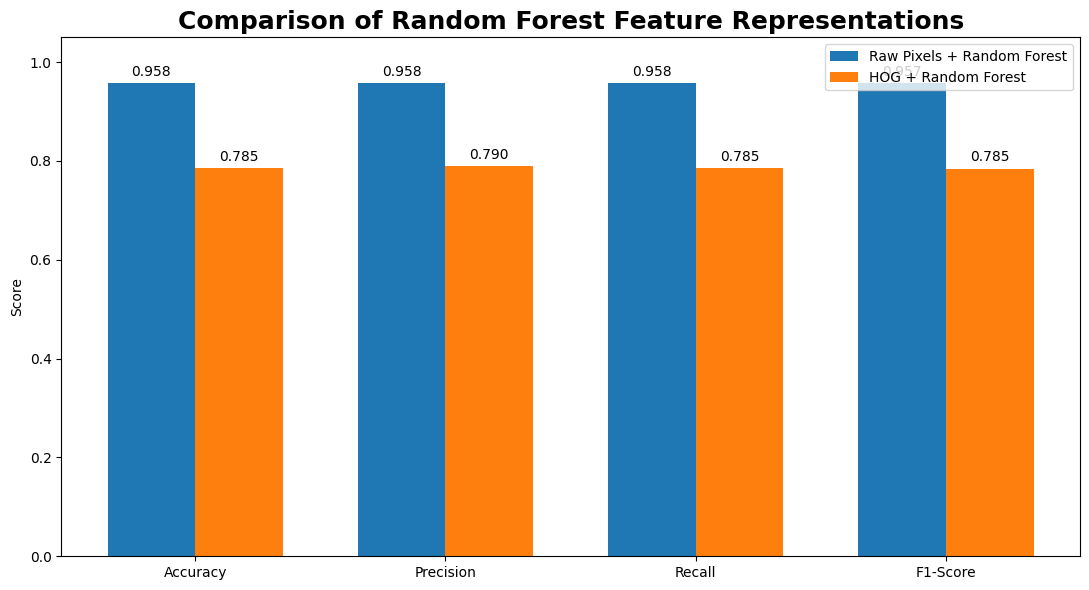

In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width / 2,
    model_comparison.iloc[0][metrics],
    width,
    label="Raw Pixels + Random Forest"
)

bars2 = ax.bar(
    x + width / 2,
    model_comparison.iloc[1][metrics],
    width,
    label="HOG + Random Forest"
)

ax.set_title(
    "Comparison of Random Forest Feature Representations",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(0, 1.05)

ax.legend()

ax.bar_label(
    bars1,
    fmt="%.3f",
    padding=3
)

ax.bar_label(
    bars2,
    fmt="%.3f",
    padding=3
)

plt.tight_layout()
plt.show()

# MODEL OPTIMIZATION

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_tuning = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train_raw,
    y_train
)

print("Hyperparameter tuning completed.")
print("\nBest parameters:")
print(random_search.best_params_)

print(
    f"\nBest cross-validation accuracy: "
    f"{random_search.best_score_:.4f}"
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Hyperparameter tuning completed.

Best parameters:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}

Best cross-validation accuracy: 0.9477


# TUNED RANDOM FOREST

In [ ]:
rf_tuned = random_search.best_estimator_

y_pred_tuned = rf_tuned.predict(
    X_test_raw
)

accuracy_tuned = accuracy_score(
    y_test,
    y_pred_tuned
)

precision_tuned = precision_score(
    y_test,
    y_pred_tuned,
    average="macro"
)

recall_tuned = recall_score(
    y_test,
    y_pred_tuned,
    average="macro"
)

f1_tuned = f1_score(
    y_test,
    y_pred_tuned,
    average="macro"
)

print("=" * 45)
print("TUNED RANDOM FOREST RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1-Score  : {f1_tuned:.4f}")

TUNED RANDOM FOREST RESULTS
Accuracy  : 0.9654
Precision : 0.9665
Recall    : 0.9654
F1-Score  : 0.9653


# CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_tuned,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        59
          10     0.9219    1.0000    0.9593        59
          11     0.9508    1.0000    0.9748        58
          12     0.9828    0.9661    0.9744        59
          13     1.0000    0.9322    0.9649        59
          14     1.0000    0.9333    0.9655        60
          15     1.0000    0.8305    0.9074        59
          16     0.9516    0.9833    0.9672        60
          17     0.9672    1.0000    0.9833        59
          18     1.0000    0.9831    0.9915        59
          19     0.9365    1.0000    0.9672        59
           2     0.9825    0.9333    0.9573        60
          20     0.9492    0.9492    0.9492        59
          21     0.9355    0.9831    0.9587        59
          22     0.9818    0.9153    0.9474        59
          23     0.8906    0.9500    0.9194        60
          24     0.9508    0.9831    0.9667        59
          25     0.9828    

# CONFUSION MATRIX

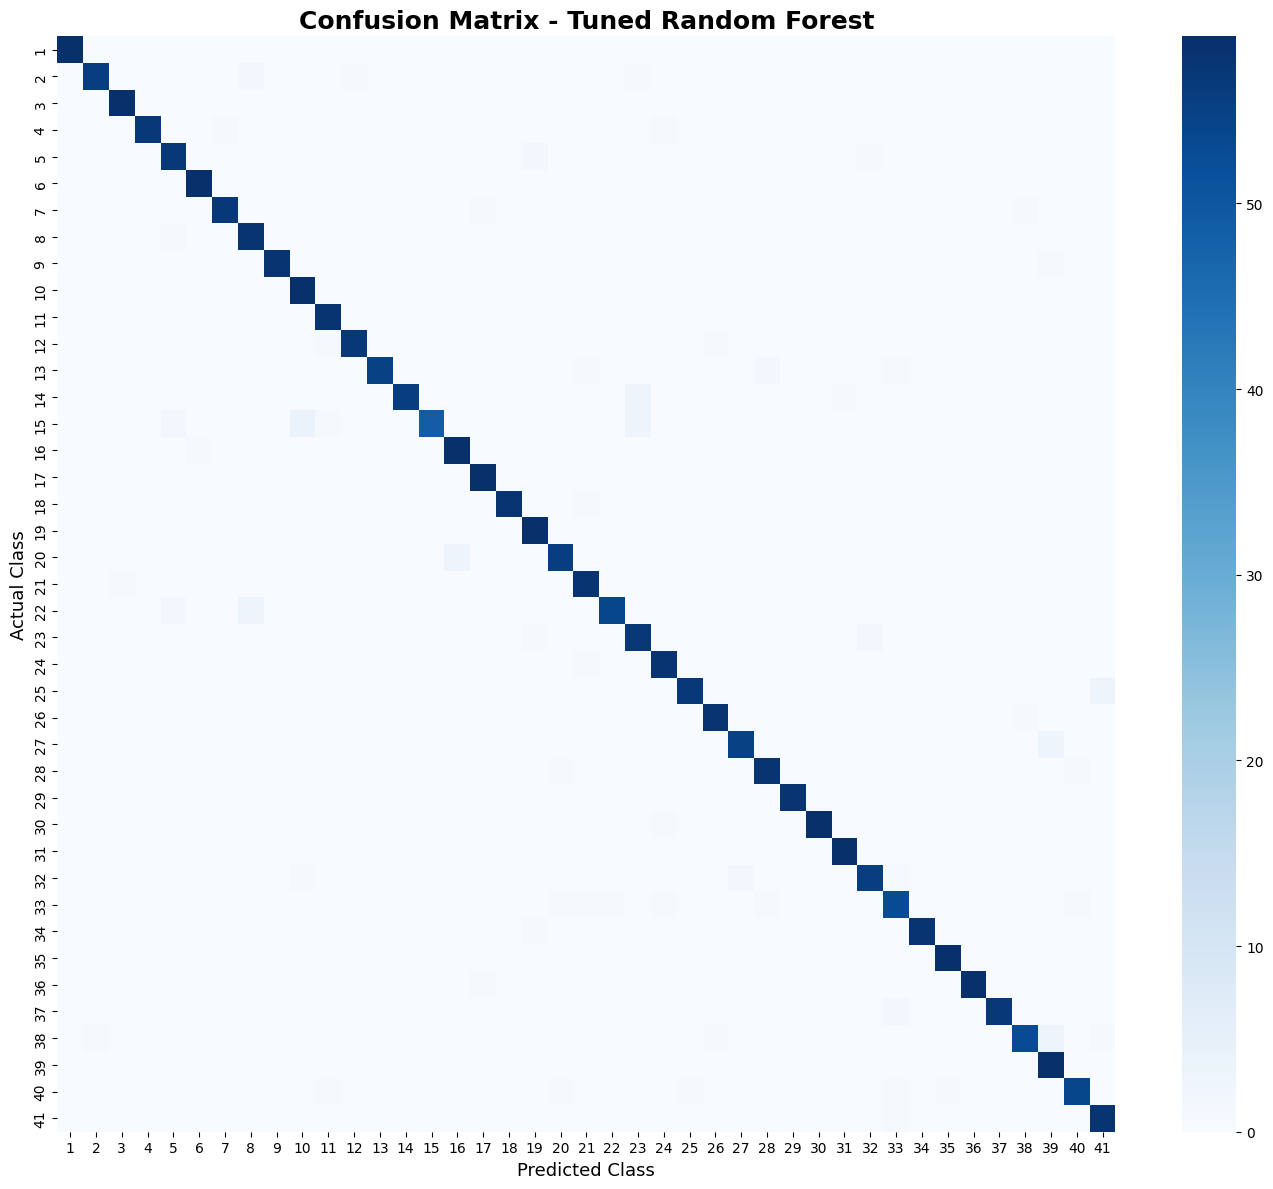

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=class_folders
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_folders,
    yticklabels=class_folders
)

plt.title(
    "Confusion Matrix - Tuned Random Forest",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Class",
    fontsize=13
)

plt.ylabel(
    "Actual Class",
    fontsize=13
)

plt.tight_layout()
plt.show()

# MOST FREQUENTLY CONFUSED CLASSES

In [ ]:
confusion_pairs = []

for i in range(len(class_folders)):
    for j in range(len(class_folders)):

        if i != j and cm[i, j] > 0:

            confusion_pairs.append({
                "Actual Class": class_folders[i],
                "Predicted Class": class_folders[j],
                "Misclassifications": cm[i, j]
            })

confusion_pairs_df = pd.DataFrame(
    confusion_pairs
)

confusion_pairs_df = confusion_pairs_df.sort_values(
    "Misclassifications",
    ascending=False
).reset_index(drop=True)

print(
    confusion_pairs_df.head(10).to_string(index=False)
)

Actual Class Predicted Class  Misclassifications
          15              10                   4
          14              23                   3
          15              23                   3
          20              16                   3
          27              39                   3
          25              41                   3
          22               8                   3
          38              39                   3
          15               5                   2
          13              28                   2


# MISCLASSIFIED CHARACTER IMAGES

In [ ]:
misclassified_indices = np.where(
    y_test != y_pred_tuned
)[0]

print(
    "Total misclassified images:",
    len(misclassified_indices)
)

print(
    "Test accuracy:",
    f"{accuracy_tuned:.2%}"
)

Total misclassified images: 84
Test accuracy: 96.54%


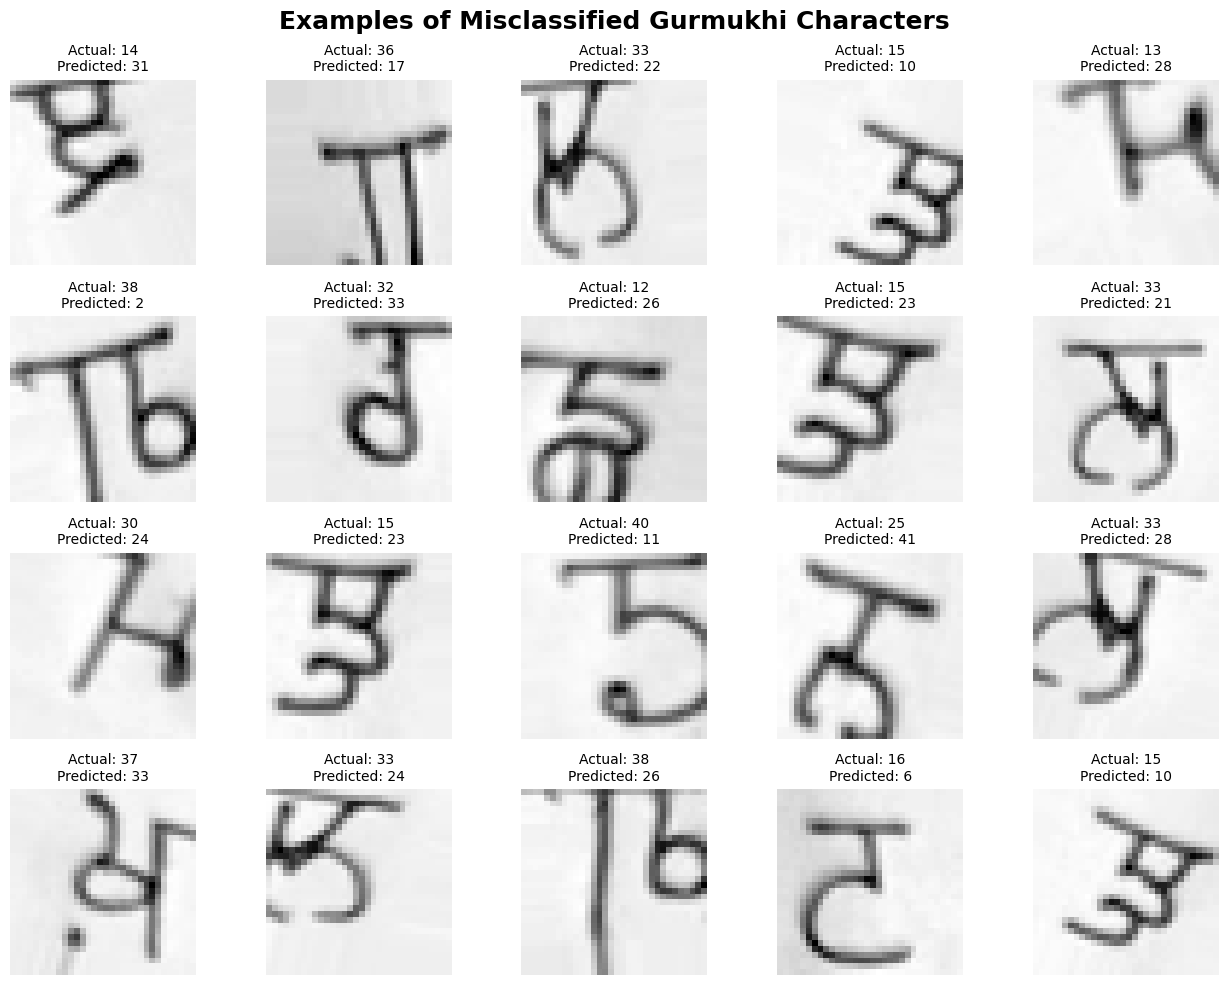

In [ ]:
num_samples = min(
    20,
    len(misclassified_indices)
)

selected_indices = np.random.choice(
    misclassified_indices,
    num_samples,
    replace=False
)

fig, axes = plt.subplots(
    4,
    5,
    figsize=(13, 10)
)

for ax, index in zip(
    axes.ravel(),
    selected_indices
):

    ax.imshow(
        X_test_img[index],
        cmap="gray"
    )

    ax.set_title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {y_pred_tuned[index]}",
        fontsize=10
    )

    ax.axis("off")

plt.suptitle(
    "Examples of Misclassified Gurmukhi Characters",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# MOST FREQUENTLY CONFUSED CLASSES

In [ ]:
confusion_pairs = []

for i in range(len(class_folders)):
    for j in range(len(class_folders)):

        if i != j and cm[i, j] > 0:

            confusion_pairs.append({
                "Actual Class": class_folders[i],
                "Predicted Class": class_folders[j],
                "Misclassifications": cm[i, j]
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

confusion_pairs_df = confusion_pairs_df.sort_values(
    "Misclassifications",
    ascending=False
).reset_index(drop=True)

display(
    confusion_pairs_df.head(10)
)

,Actual Class,Predicted Class,Misclassifications
0,15,10,4
1,14,23,3
2,15,23,3
3,20,16,3
4,27,39,3
5,25,41,3
6,22,8,3
7,38,39,3
8,15,5,2
9,13,28,2


# TOP CONFUSION PAIRS

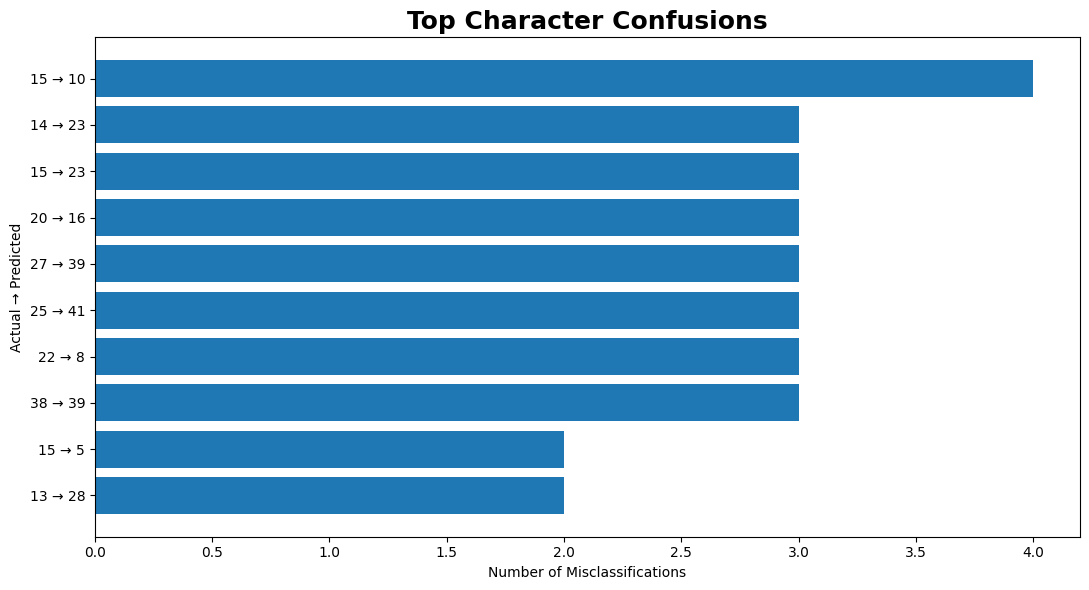

In [ ]:
top_confusions = confusion_pairs_df.head(10).copy()

top_confusions["Pair"] = (
    top_confusions["Actual Class"].astype(str)
    + " → "
    + top_confusions["Predicted Class"].astype(str)
)

plt.figure(figsize=(11, 6))

plt.barh(
    top_confusions["Pair"][::-1],
    top_confusions["Misclassifications"][::-1]
)

plt.title(
    "Top Character Confusions",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Misclassifications")
plt.ylabel("Actual → Predicted")

plt.tight_layout()
plt.show()

# PREDICTION CONFIDENCE ANALYSIS

In [ ]:
prediction_probabilities = rf_tuned.predict_proba(X_test_raw)

prediction_confidence = np.max(
    prediction_probabilities,
    axis=1
)

confidence_results = pd.DataFrame({
    "Actual Class": y_test,
    "Predicted Class": y_pred_tuned,
    "Confidence": prediction_confidence
})

confidence_results["Correct"] = (
    confidence_results["Actual Class"]
    == confidence_results["Predicted Class"]
)

print(
    f"Average prediction confidence: "
    f"{prediction_confidence.mean():.2%}"
)

print(
    f"Correct predictions: "
    f"{confidence_results['Correct'].mean():.2%}"
)

Average prediction confidence: 41.51%
Correct predictions: 96.54%


# CONFIDENCE DISTRIBUTION

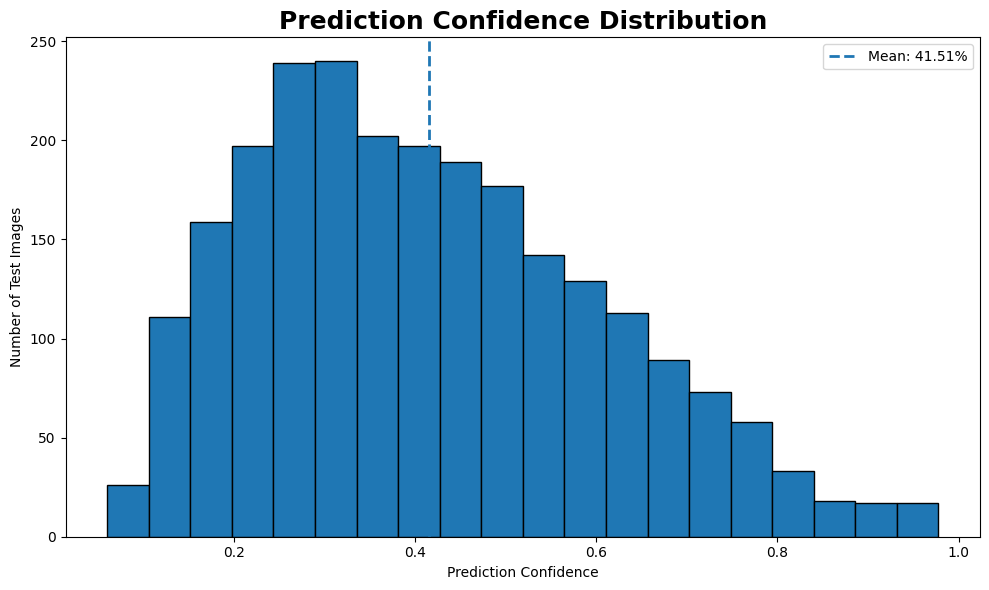

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    prediction_confidence,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    prediction_confidence.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean: {prediction_confidence.mean():.2%}"
)

plt.title(
    "Prediction Confidence Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Test Images")

plt.legend()

plt.tight_layout()
plt.show()

# LOW-CONFIDENCE PREDICTIONS

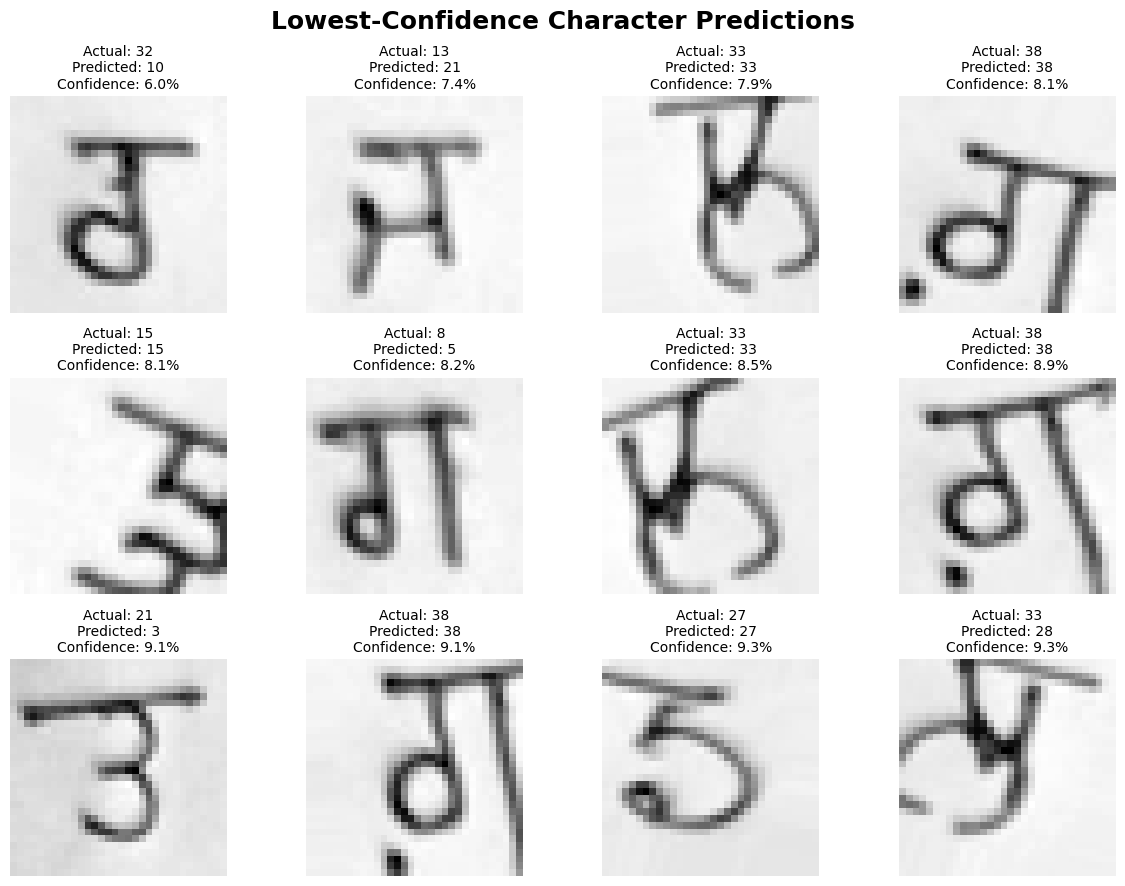

In [ ]:
low_confidence_indices = np.argsort(
    prediction_confidence
)[:12]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9)
)

for ax, index in zip(
    axes.ravel(),
    low_confidence_indices
):

    ax.imshow(
        X_test_img[index],
        cmap="gray"
    )

    ax.set_title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {y_pred_tuned[index]}\n"
        f"Confidence: {prediction_confidence[index]:.1%}",
        fontsize=10
    )

    ax.axis("off")

plt.suptitle(
    "Lowest-Confidence Character Predictions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# UNSEEN CHARACTER PREDICTION

In [ ]:
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

image = Image.open(
    io.BytesIO(uploaded[file_name])
).convert("L")

print("Uploaded image:", file_name)
print("Original image size:", image.size)

Saving aug_0_976.jpg to aug_0_976.jpg
Uploaded image: aug_0_976.jpg
Original image size: (256, 256)


# PREPROCESS UNSEEN IMAGE

In [ ]:
image_resized = image.resize((32, 32))

image_array = np.array(
    image_resized,
    dtype=np.float32
) / 255.0

image_input = image_array.reshape(
    1,
    -1
)

print("Processed image shape:", image_input.shape)

Processed image shape: (1, 1024)


# PREDICT UNSEEN CHARACTER

In [ ]:
unseen_prediction = rf_tuned.predict(
    image_input
)[0]

unseen_probabilities = rf_tuned.predict_proba(
    image_input
)[0]

unseen_confidence = np.max(
    unseen_probabilities
)

print("=" * 45)
print("UNSEEN CHARACTER PREDICTION")
print("=" * 45)

print("Predicted Class :", unseen_prediction)
print(
    f"Confidence      : {unseen_confidence:.2%}"
)

UNSEEN CHARACTER PREDICTION
Predicted Class : 30
Confidence      : 86.45%


# VISUALIZE UNSEEN PREDICTION

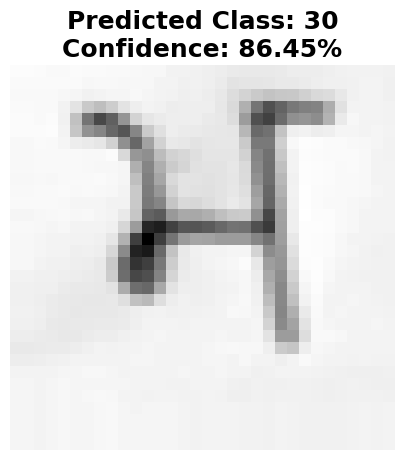

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(
    image_array,
    cmap="gray"
)

plt.title(
    f"Predicted Class: {unseen_prediction}\n"
    f"Confidence: {unseen_confidence:.2%}",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.show()

# TOP 5 PREDICTIONS

In [ ]:
top_5_indices = np.argsort(
    unseen_probabilities
)[-5:][::-1]

top_5_classes = [
    rf_tuned.classes_[i]
    for i in top_5_indices
]

top_5_probabilities = [
    unseen_probabilities[i]
    for i in top_5_indices
]

top_5_results = pd.DataFrame({
    "Class": top_5_classes,
    "Probability": top_5_probabilities
})

top_5_results["Probability"] = (
    top_5_results["Probability"]
    .map(lambda x: f"{x:.2%}")
)

display(top_5_results)

,Class,Probability
0,30,86.45%
1,39,3.29%
2,9,2.47%
3,13,1.56%
4,28,1.23%


# TOP 5 PREDICTION PROBABILITIES

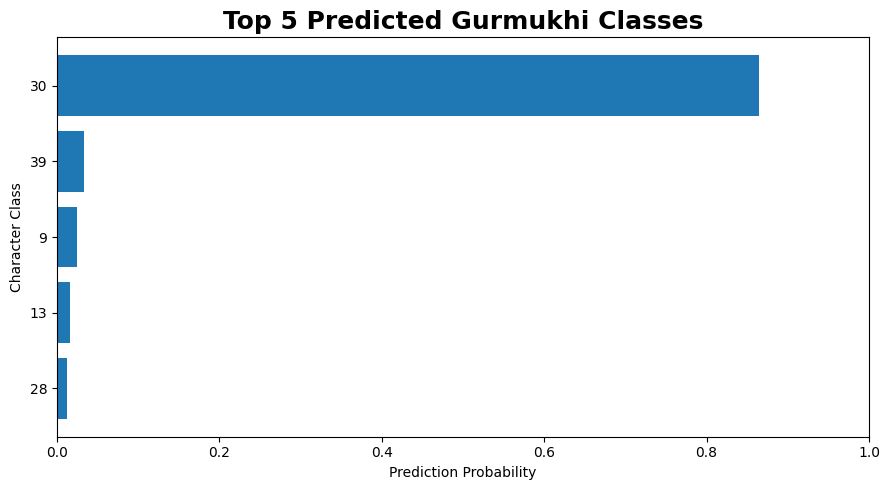

In [ ]:
plt.figure(figsize=(9, 5))

plt.barh(
    top_5_results["Class"].astype(str)[::-1],
    top_5_probabilities[::-1]
)

plt.xlabel("Prediction Probability")

plt.ylabel("Character Class")

plt.title(
    "Top 5 Predicted Gurmukhi Classes",
    fontsize=18,
    fontweight="bold"
)

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

# CLASS-WISE PERFORMANCE

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision_class, recall_class, f1_class, support_class = (
    precision_recall_fscore_support(
        y_test,
        y_pred_tuned,
        labels=class_folders,
        zero_division=0
    )
)

class_performance = pd.DataFrame({
    "Class": class_folders,
    "Precision": precision_class,
    "Recall": recall_class,
    "F1-Score": f1_class,
    "Support": support_class
})

display(
    class_performance.style.format({
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}"
    })
)

,Class,Precision,Recall,F1-Score,Support
0,1,100.00%,100.00%,100.00%,59
1,2,98.25%,93.33%,95.73%,60
2,3,98.33%,100.00%,99.16%,59
3,4,100.00%,96.61%,98.28%,59
4,5,91.94%,95.00%,93.44%,60
5,6,98.33%,100.00%,99.16%,59
6,7,98.28%,96.61%,97.44%,59
7,8,92.06%,98.31%,95.08%,59
8,9,100.00%,98.31%,99.15%,59
9,10,92.19%,100.00%,95.93%,59


# CLASS-WISE F1-SCORE

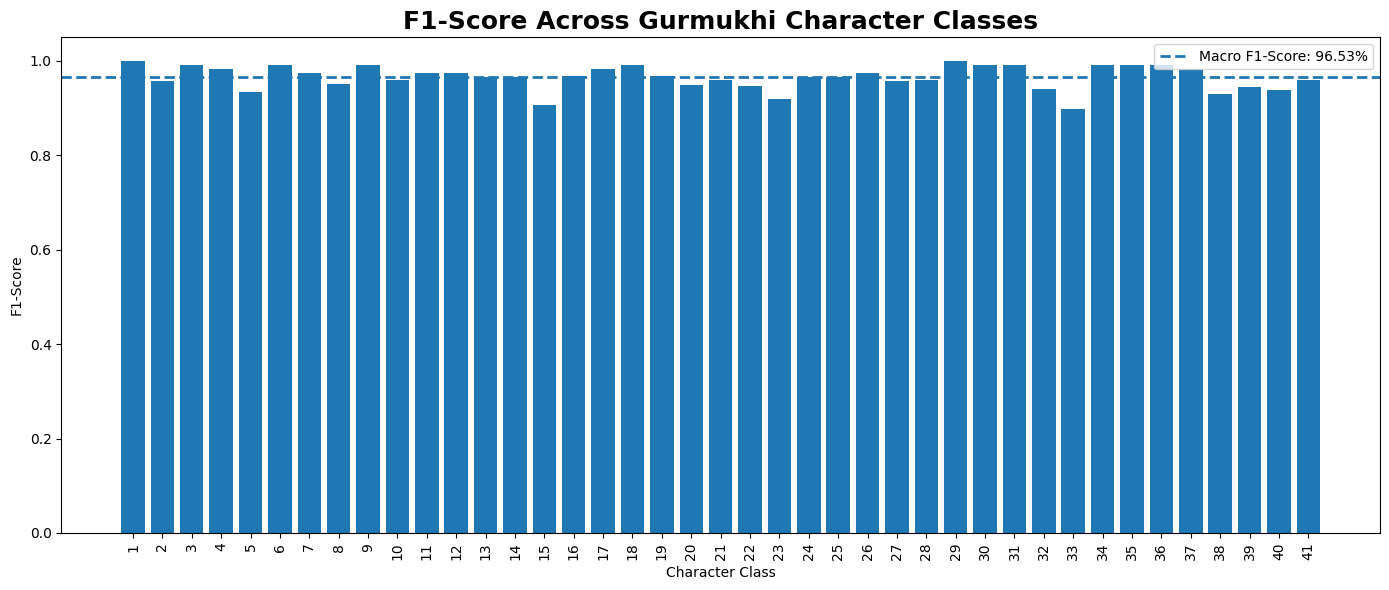

In [ ]:
plt.figure(figsize=(14, 6))

plt.bar(
    class_performance["Class"].astype(str),
    class_performance["F1-Score"]
)

plt.axhline(
    f1_tuned,
    linestyle="--",
    linewidth=2,
    label=f"Macro F1-Score: {f1_tuned:.2%}"
)

plt.title(
    "F1-Score Across Gurmukhi Character Classes",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Character Class")
plt.ylabel("F1-Score")

plt.ylim(0, 1.05)

plt.legend()

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# FINAL MODEL SUMMARY

In [ ]:
final_summary = pd.DataFrame({
    "Metric": [
        "Number of Classes",
        "Total Images",
        "Training Images",
        "Testing Images",
        "Image Size",
        "Baseline RF Accuracy",
        "HOG + RF Accuracy",
        "Tuned RF Accuracy",
        "Tuned RF Precision",
        "Tuned RF Recall",
        "Tuned RF F1-Score"
    ],
    "Value": [
        len(class_folders),
        len(X_images),
        len(X_train_raw),
        len(X_test_raw),
        "32 × 32",
        f"{accuracy_raw:.2%}",
        f"{accuracy_hog:.2%}",
        f"{accuracy_tuned:.2%}",
        f"{precision_tuned:.2%}",
        f"{recall_tuned:.2%}",
        f"{f1_tuned:.2%}"
    ]
})

display(final_summary)

,Metric,Value
0,Number of Classes,41
1,Total Images,12128
2,Training Images,9702
3,Testing Images,2426
4,Image Size,32 × 32
5,Baseline RF Accuracy,95.75%
6,HOG + RF Accuracy,78.52%
7,Tuned RF Accuracy,96.54%
8,Tuned RF Precision,96.65%
9,Tuned RF Recall,96.54%


# SAVE TRAINED MODEL

In [ ]:
import joblib

model_filename = "gurmukhi_random_forest_model.pkl"

joblib.dump(
    rf_tuned,
    model_filename
)

print("Final model saved successfully.")
print("File:", model_filename)

Final model saved successfully.
File: gurmukhi_random_forest_model.pkl


In [ ]:
from google.colab import files

files.download(
    "gurmukhi_random_forest_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SAVE CLASS LABELS

In [ ]:
import json

class_labels = [
    str(label)
    for label in rf_tuned.classes_
]

with open(
    "gurmukhi_class_labels.json",
    "w"
) as file:

    json.dump(
        class_labels,
        file,
        indent=4
    )

print("Class labels saved successfully.")

Class labels saved successfully.


In [ ]:
files.download(
    "gurmukhi_class_labels.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# CONCLUSION
This project developed a Random Forest-based handwritten Gurmukhi character recognition system using a publicly available labeled dataset containing 41 character classes.

The dataset was explored and preprocessed by converting the character images to grayscale, resizing them to 32 × 32 pixels, and normalizing the pixel values. Two feature representations were investigated: raw pixel features and Histogram of Oriented Gradients (HOG) features.

A baseline Random Forest model using raw pixel features achieved an accuracy of 95.75%. The HOG-based Random Forest achieved 78.52%, demonstrating that the selected feature representation had a significant effect on classification performance.

Hyperparameter optimization was then performed using RandomizedSearchCV with 3-fold cross-validation. The optimized Random Forest achieved a test accuracy of 96.54%, with macro precision of 96.65%, macro recall of 96.54%, and macro F1-score of 96.53%.

The model was further evaluated using a classification report, confusion matrix, class-wise performance analysis, confidence analysis, and visualization of misclassified characters. An unseen-image prediction module was also developed, allowing a new handwritten character image to be uploaded and classified by the trained model.

The final system demonstrates that Random Forest combined with suitable image preprocessing and feature representation can effectively recognize handwritten Gurmukhi characters.